In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

import re
import nltk
import pymorphy3

import gensim

import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [ ]:
import pandas as pd
import os

df_habr = pd.read_csv("habr.csv")
df_pdf = pd.read_csv("habrpdf.csv")

df_habr_standard = pd.DataFrame({
    'title': df_habr['title'],
    'namecompany': df_habr['namecompany'],
    'description': df_habr['description'],
    'rating': df_habr['rating'],
    'field': df_habr['field'],
    'date': df_habr['date'],
    'textpub': df_habr['textpub']
})

df_pdf_standard = pd.DataFrame({
    'title': df_pdf['NameCompany'],
    'namecompany': df_pdf['NameCompany'],
    'description': df_pdf['Description'],
    'rating': df_pdf['Raiting'],
    'field': df_pdf['Activity'],
    'date': df_pdf['DataPublish'],
    'textpub': df_pdf['TextArticle']
})

df_combined = pd.concat([df_habr_standard, df_pdf_standard], ignore_index=True)

df_combined.to_csv("All_Habr.csv", index=False)


In [3]:
df = pd.read_csv('All_Habr.csv')

In [4]:
df.head()

,title,namecompany,description,rating,field,date,textpub
0,Владислав Бакальчук стал генеральным директоро...,М.Видео-Эльдорадо,30 лет в топе,103.68,Электронная коммерция,2026-03-13,Совет директоров «М.Видео» избрал Феликса Либа...
1,"RxJS в Angular: 5 операторов, которые превраща...",RUVDS.com,VDS/VPS-хостинг. Скидка 15% по коду HABR15,3055.47,"Связь и телекоммуникации, Домены и хостинг, Ве...",2026-03-13,Стоит начать с боли всех разработчиков Angular...
2,У американских законодателей возникли вопросы ...,BotHub,Российский Openrouter,429.67,"Веб-разработка, Программное обеспечение, Веб-с...",2026-03-13,Спешно заключенная OpenAI сделка с Министерств...
3,"Где брать операторов поддержки, которых не зам...",TEAMLY,Компания,24.17,"Программное обеспечение, Веб-сервисы",2026-03-13,"Чат-боты победили рутину, но вместе с ней унич..."
4,Фамипия. Оживляем раритетный домофон с тремя р...,Timeweb Cloud,То самое облако,2178.95,Связь и телекоммуникации,2026-03-13,Приветствую всех!Не так давно я уже рассказыва...


In [5]:
df['textpub'][0]

'Совет директоров «М.Видео» избрал Феликса Либа председателем и назначил Владислава Бакальчука генеральным директором Компании. «Прошедший год стал для М.Видео переломным. Мы реализовали глубокую трансформацию бизнес-модели. Ключевым стратегическим шагом стал переход на агентскую схему поставок с крупнейшими поставщиками. Если ранее Компания работала по классической модели выкупа товара, что требовало значительного оборотного капитала и привлечения заемного финансирования, то сегодня мы реализуем продукцию по агентской модели, рассчитываясь с поставщиками по факту продаж.Этот шаг позволил существенно снизить финансовую нагрузку в условиях высокой ключевой ставки, сохранить устойчивость бизнеса и заложить фундамент для долгосрочного развития. Нам удалось обеспечить насыщенность складов и широкий ассортимент продукции ведущих брендов-партнеров для наших покупателей. По сути, была создана новая модель работы с рынком, аналогов которой в отрасли ранее не было.Несмотря на охлаждение потреби

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   title        69 non-null     str  
 1   namecompany  69 non-null     str  
 2   description  69 non-null     str  
 3   rating       69 non-null     str  
 4   field        67 non-null     str  
 5   date         69 non-null     str  
 6   textpub      69 non-null     str  
dtypes: str(7)
memory usage: 3.9 KB


In [7]:
df['corpus'] = (df['title'].fillna('') + ' ' + 
                df['textpub'].fillna(''))

### Предобработка текста

In [8]:
st = '\xa0—'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [9]:
df['prep_text']= [remove_othersymbol(text.lower()) for text in df['corpus']]

In [10]:
df['prep_text'][0]

'владислав бакальчук стал генеральным директором «м.видео» совет директоров «м.видео» избрал феликса либа председателем и назначил владислава бакальчука генеральным директором компании. «прошедший год стал для м.видео переломным. мы реализовали глубокую трансформацию бизнес-модели. ключевым стратегическим шагом стал переход на агентскую схему поставок с крупнейшими поставщиками. если ранее компания работала по классической модели выкупа товара, что требовало значительного оборотного капитала и привлечения заемного финансирования, то сегодня мы реализуем продукцию по агентской модели, рассчитываясь с поставщиками по факту продаж.этот шаг позволил существенно снизить финансовую нагрузку в условиях высокой ключевой ставки, сохранить устойчивость бизнеса и заложить фундамент для долгосрочного развития. нам удалось обеспечить насыщенность складов и широкий ассортимент продукции ведущих брендов-партнеров для наших покупателей. по сути, была создана новая модель работы с рынком, аналогов кото

In [11]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [12]:
df['prep_text']= [remove_punctuation(text) for text in df['prep_text']]

In [13]:
df['prep_text'][0]

'владислав бакальчук стал генеральным директором «мвидео» совет директоров «мвидео» избрал феликса либа председателем и назначил владислава бакальчука генеральным директором компании «прошедший год стал для мвидео переломным мы реализовали глубокую трансформацию бизнесмодели ключевым стратегическим шагом стал переход на агентскую схему поставок с крупнейшими поставщиками если ранее компания работала по классической модели выкупа товара что требовало значительного оборотного капитала и привлечения заемного финансирования то сегодня мы реализуем продукцию по агентской модели рассчитываясь с поставщиками по факту продажэтот шаг позволил существенно снизить финансовую нагрузку в условиях высокой ключевой ставки сохранить устойчивость бизнеса и заложить фундамент для долгосрочного развития нам удалось обеспечить насыщенность складов и широкий ассортимент продукции ведущих брендовпартнеров для наших покупателей по сути была создана новая модель работы с рынком аналогов которой в отрасли ране

In [14]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text
0,Владислав Бакальчук стал генеральным директоро...,М.Видео-Эльдорадо,30 лет в топе,103.68,Электронная коммерция,2026-03-13,Совет директоров «М.Видео» избрал Феликса Либа...,Владислав Бакальчук стал генеральным директоро...,владислав бакальчук стал генеральным директоро...
1,"RxJS в Angular: 5 операторов, которые превраща...",RUVDS.com,VDS/VPS-хостинг. Скидка 15% по коду HABR15,3055.47,"Связь и телекоммуникации, Домены и хостинг, Ве...",2026-03-13,Стоит начать с боли всех разработчиков Angular...,"RxJS в Angular: 5 операторов, которые превраща...",rxjs в angular 5 операторов которые превращают...
2,У американских законодателей возникли вопросы ...,BotHub,Российский Openrouter,429.67,"Веб-разработка, Программное обеспечение, Веб-с...",2026-03-13,Спешно заключенная OpenAI сделка с Министерств...,У американских законодателей возникли вопросы ...,у американских законодателей возникли вопросы ...
3,"Где брать операторов поддержки, которых не зам...",TEAMLY,Компания,24.17,"Программное обеспечение, Веб-сервисы",2026-03-13,"Чат-боты победили рутину, но вместе с ней унич...","Где брать операторов поддержки, которых не зам...",где брать операторов поддержки которых не заме...
4,Фамипия. Оживляем раритетный домофон с тремя р...,Timeweb Cloud,То самое облако,2178.95,Связь и телекоммуникации,2026-03-13,Приветствую всех!Не так давно я уже рассказыва...,Фамипия. Оживляем раритетный домофон с тремя р...,фамипия оживляем раритетный домофон с тремя ру...


In [15]:
import nltk
nltk.download('stopwords')
russian_stopwords = stopwords.words("russian") 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный','фильм', 'кино', 'смотреть', 'год', 'снят', 'рассказывает', 'история', 
                'оказывается', 'вдруг', 'наконец', 'также', 'который', 'который', 'этот', 'эта', 'это', 'эти', 'подписаться', 'каждый', 'просто', 'очень', 'назад', 
                'час назад', 'простой', 'март', 'привет хабр', 'то есть', 'подписаться', 'каждый', 'просто', 'очень', 'назад', 'час назад', 
                'простой', 'март', 'хороший', 'несколько', 'нужно', 'прямо', 'вместе', 'общий', 'разный', 'особый', 'целое', 'часть', 'результат', 'слово', 'порядок', 'подход', 'ответ', 
                'параметр', 'делегировать', 'требоваться', 'использование', 'час', 'день', 'понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье', 'число', 'сутки',
                'сегодняшний', 'банально', 'например', 'ия']) 

In [17]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [19]:
%%time
lemm_texts_list = []
for text in (df['prep_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 6.7 s
Wall time: 6.89 s


In [20]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm
0,Владислав Бакальчук стал генеральным директоро...,М.Видео-Эльдорадо,30 лет в топе,103.68,Электронная коммерция,2026-03-13,Совет директоров «М.Видео» избрал Феликса Либа...,Владислав Бакальчук стал генеральным директоро...,владислав бакальчук стал генеральным директоро...,владислав бакальчук стать генеральный директор...
1,"RxJS в Angular: 5 операторов, которые превраща...",RUVDS.com,VDS/VPS-хостинг. Скидка 15% по коду HABR15,3055.47,"Связь и телекоммуникации, Домены и хостинг, Ве...",2026-03-13,Стоит начать с боли всех разработчиков Angular...,"RxJS в Angular: 5 операторов, которые превраща...",rxjs в angular 5 операторов которые превращают...,rxjs в angular 5 оператор который превращать х...
2,У американских законодателей возникли вопросы ...,BotHub,Российский Openrouter,429.67,"Веб-разработка, Программное обеспечение, Веб-с...",2026-03-13,Спешно заключенная OpenAI сделка с Министерств...,У американских законодателей возникли вопросы ...,у американских законодателей возникли вопросы ...,у американский законодатель возникнуть вопрос ...
3,"Где брать операторов поддержки, которых не зам...",TEAMLY,Компания,24.17,"Программное обеспечение, Веб-сервисы",2026-03-13,"Чат-боты победили рутину, но вместе с ней унич...","Где брать операторов поддержки, которых не зам...",где брать операторов поддержки которых не заме...,где брать оператор поддержка который не замени...
4,Фамипия. Оживляем раритетный домофон с тремя р...,Timeweb Cloud,То самое облако,2178.95,Связь и телекоммуникации,2026-03-13,Приветствую всех!Не так давно я уже рассказыва...,Фамипия. Оживляем раритетный домофон с тремя р...,фамипия оживляем раритетный домофон с тремя ру...,фамипий оживлять раритетный домофон с три ручк...


In [21]:
df['text_lemm'][0]

'владислав бакальчук стать генеральный директор « мвидео » совет директор « мвидео » избрать феликс либ председатель и назначить владислав бакальчук генеральный директор компания « прошедший год стать для мвидео переломный мы реализовать глубокий трансформация бизнесмодель ключевой стратегический шаг стать переход на агентский схема поставка с крупный поставщик если ранее компания работать по классический модель выкуп товар что требовать значительный оборотный капитал и привлечение заёмный финансирование то сегодня мы реализовать продукция по агентский модель рассчитываться с поставщик по факт продажэтота шаг позволить существенно снизить финансовый нагрузка в условие высокий ключевой ставка сохранить устойчивость бизнес и заложить фундамент для долгосрочный развитие мы удаться обеспечить насыщенность склад и широкий ассортимент продукция ведущий брендовпартнер для наш покупатель по суть быть создать новый модель работа с рынок аналог который в отрасль ранее не былонесмотрить на охлажд

In [22]:
def clean_textpub(text):
    text = re.sub(r'\b\w*\d\w*\b', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    return text

In [23]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(t) > 2]
    text = " ".join(tokens)
    return clean_textpub(text)

In [24]:
df['tokenize_text'] = [tokenize(text) for text in df['text_lemm']]

In [25]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text
0,Владислав Бакальчук стал генеральным директоро...,М.Видео-Эльдорадо,30 лет в топе,103.68,Электронная коммерция,2026-03-13,Совет директоров «М.Видео» избрал Феликса Либа...,Владислав Бакальчук стал генеральным директоро...,владислав бакальчук стал генеральным директоро...,владислав бакальчук стать генеральный директор...,владислав бакальчук стать генеральный директор...
1,"RxJS в Angular: 5 операторов, которые превраща...",RUVDS.com,VDS/VPS-хостинг. Скидка 15% по коду HABR15,3055.47,"Связь и телекоммуникации, Домены и хостинг, Ве...",2026-03-13,Стоит начать с боли всех разработчиков Angular...,"RxJS в Angular: 5 операторов, которые превраща...",rxjs в angular 5 операторов которые превращают...,rxjs в angular 5 оператор который превращать х...,rxjs angular оператор превращать хаос данные...
2,У американских законодателей возникли вопросы ...,BotHub,Российский Openrouter,429.67,"Веб-разработка, Программное обеспечение, Веб-с...",2026-03-13,Спешно заключенная OpenAI сделка с Министерств...,У американских законодателей возникли вопросы ...,у американских законодателей возникли вопросы ...,у американский законодатель возникнуть вопрос ...,американский законодатель возникнуть вопрос op...
3,"Где брать операторов поддержки, которых не зам...",TEAMLY,Компания,24.17,"Программное обеспечение, Веб-сервисы",2026-03-13,"Чат-боты победили рутину, но вместе с ней унич...","Где брать операторов поддержки, которых не зам...",где брать операторов поддержки которых не заме...,где брать оператор поддержка который не замени...,брать оператор поддержка заменить чатбот чатбо...
4,Фамипия. Оживляем раритетный домофон с тремя р...,Timeweb Cloud,То самое облако,2178.95,Связь и телекоммуникации,2026-03-13,Приветствую всех!Не так давно я уже рассказыва...,Фамипия. Оживляем раритетный домофон с тремя р...,фамипия оживляем раритетный домофон с тремя ру...,фамипий оживлять раритетный домофон с три ручк...,фамипий оживлять раритетный домофон ручка прив...


In [26]:
df['tokenize_text'][0]

'владислав бакальчук стать генеральный директор   мвидео   совет директор   мвидео   избрать феликс либ председатель назначить владислав бакальчук генеральный директор компания   прошедший стать мвидео переломный реализовать глубокий трансформация бизнесмодель ключевой стратегический шаг стать переход агентский схема поставка крупный поставщик ранее компания работать классический модель выкуп товар требовать значительный оборотный капитал привлечение заёмный финансирование сегодня реализовать продукция агентский модель рассчитываться поставщик факт продажэтота шаг позволить существенно снизить финансовый нагрузка условие высокий ключевой ставка сохранить устойчивость бизнес заложить фундамент долгосрочный развитие удаться обеспечить насыщенность склад широкий ассортимент продукция ведущий брендовпартнер наш покупатель суть создать новый модель работа рынок аналог отрасль ранее былонесмотрить охлаждение потребительский спрос экономический вызов компания укрепить позиция омниканальный пл

In [27]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

<Axes: >

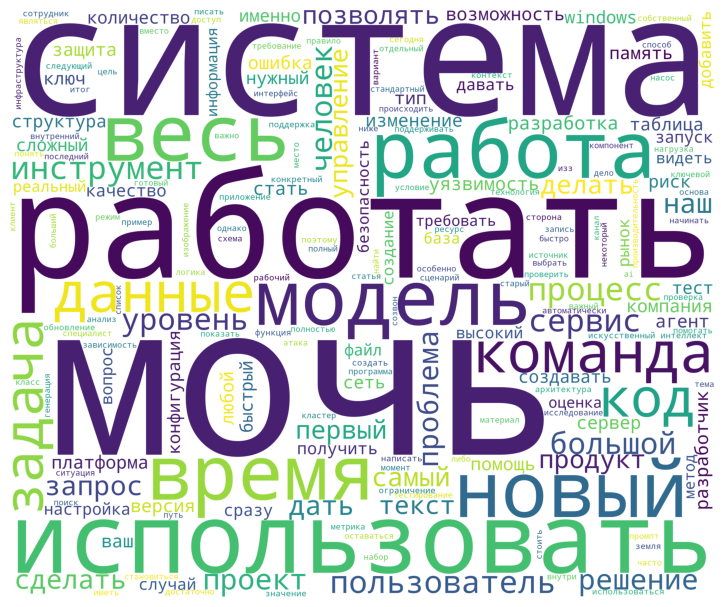

In [29]:
corpus = get_corpus(df['tokenize_text'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [30]:
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

<Axes: >

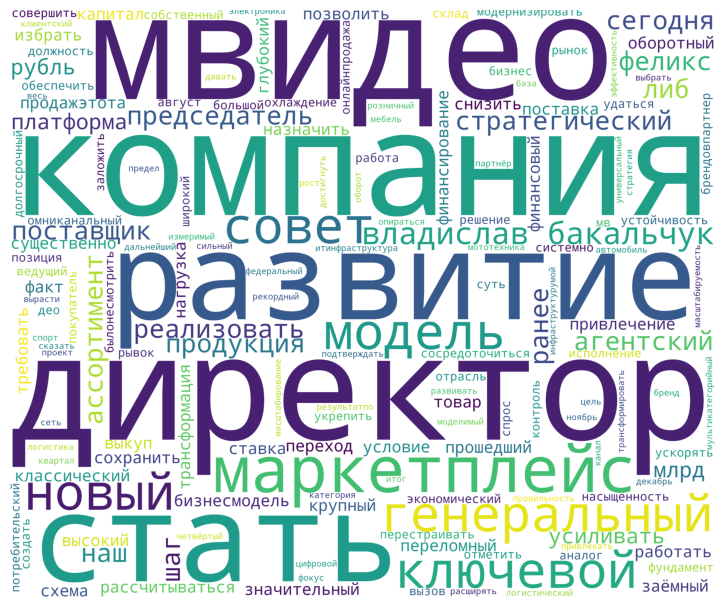

In [31]:
corpus = df['tokenize_text'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

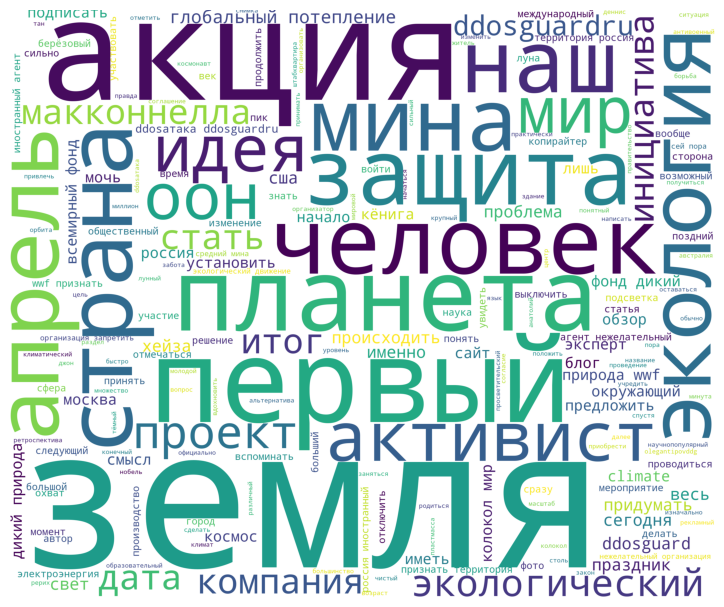

In [32]:
corpus = df['tokenize_text'][len(df)-1]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

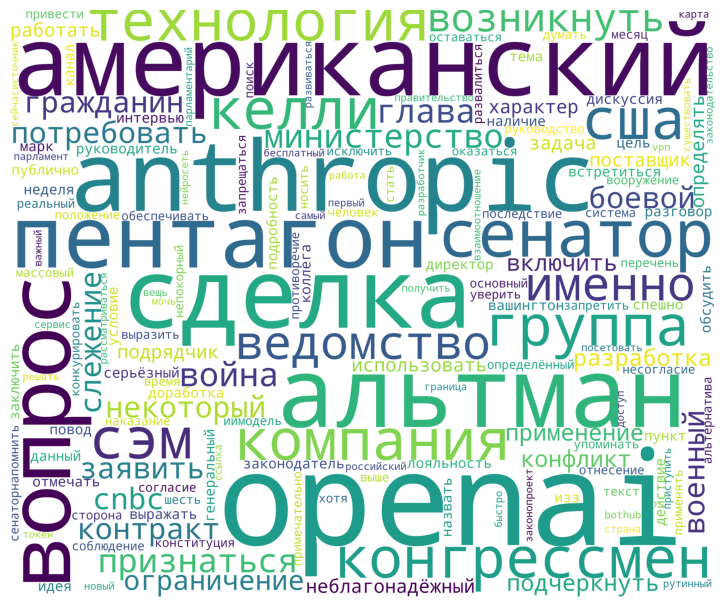

In [33]:
corpus = df['tokenize_text'][2]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [34]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text
0,Владислав Бакальчук стал генеральным директоро...,М.Видео-Эльдорадо,30 лет в топе,103.68,Электронная коммерция,2026-03-13,Совет директоров «М.Видео» избрал Феликса Либа...,Владислав Бакальчук стал генеральным директоро...,владислав бакальчук стал генеральным директоро...,владислав бакальчук стать генеральный директор...,владислав бакальчук стать генеральный директор...
1,"RxJS в Angular: 5 операторов, которые превраща...",RUVDS.com,VDS/VPS-хостинг. Скидка 15% по коду HABR15,3055.47,"Связь и телекоммуникации, Домены и хостинг, Ве...",2026-03-13,Стоит начать с боли всех разработчиков Angular...,"RxJS в Angular: 5 операторов, которые превраща...",rxjs в angular 5 операторов которые превращают...,rxjs в angular 5 оператор который превращать х...,rxjs angular оператор превращать хаос данные...
2,У американских законодателей возникли вопросы ...,BotHub,Российский Openrouter,429.67,"Веб-разработка, Программное обеспечение, Веб-с...",2026-03-13,Спешно заключенная OpenAI сделка с Министерств...,У американских законодателей возникли вопросы ...,у американских законодателей возникли вопросы ...,у американский законодатель возникнуть вопрос ...,американский законодатель возникнуть вопрос op...
3,"Где брать операторов поддержки, которых не зам...",TEAMLY,Компания,24.17,"Программное обеспечение, Веб-сервисы",2026-03-13,"Чат-боты победили рутину, но вместе с ней унич...","Где брать операторов поддержки, которых не зам...",где брать операторов поддержки которых не заме...,где брать оператор поддержка который не замени...,брать оператор поддержка заменить чатбот чатбо...
4,Фамипия. Оживляем раритетный домофон с тремя р...,Timeweb Cloud,То самое облако,2178.95,Связь и телекоммуникации,2026-03-13,Приветствую всех!Не так давно я уже рассказыва...,Фамипия. Оживляем раритетный домофон с тремя р...,фамипия оживляем раритетный домофон с тремя ру...,фамипий оживлять раритетный домофон с три ручк...,фамипий оживлять раритетный домофон ручка прив...


# Векторизация текстовых данных

### Bag of words

In [35]:
count_vec = CountVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3), analyzer='word')
count_matrix = count_vec.fit_transform(df['tokenize_text'])

feature_names = count_vec.get_feature_names_out()

In [36]:
len(count_vec.vocabulary_)

3813

In [37]:
count_matrix.shape

(69, 3813)

In [38]:
feature_names

array(['ac', 'account', 'ace', ..., 'ясно', 'ящик', 'ёмкость'],
      shape=(3813,), dtype=object)

### TF-IDF

In [39]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,         
    min_df=3,            
    max_features=5000,   
    ngram_range=(1, 3),  
    analyzer='word'
)

In [40]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenize_text'])

In [41]:
tfidf_matrix.shape

(69, 3813)

In [42]:
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 28797 stored elements and shape (69, 3813)>
  Coords	Values
  (0, 730)	0.21235755550035637
  (0, 865)	0.34510616869979244
  (0, 3112)	0.21235755550035637
  (0, 1696)	0.07799761874236984
  (0, 1353)	0.1854208567487649
  (0, 2696)	0.07799761874236984
  (0, 2819)	0.09656904589200747
  (0, 752)	0.05176786721712181
  (0, 3409)	0.07408983549322996
  (0, 1317)	0.13313021909059156
  (0, 3285)	0.16556071780766954
  (0, 3741)	0.09656904589200747
  (0, 2198)	0.05054276418444212
  (0, 3323)	0.04624169525924388
  (0, 1447)	0.04723878052466427
  (0, 2421)	0.13584762201130343
  (0, 2783)	0.11185860787053814
  (0, 1309)	0.05054276418444212
  (0, 1638)	0.1088700476268633
  (0, 3385)	0.06539931208262517
  (0, 3415)	0.0362900158756211
  (0, 1116)	0.061098243157426936
  (0, 1882)	0.08278035890383477
  (0, 2533)	0.08278035890383477
  (0, 2973)	0.08875347939372771
  :	:
  (68, 1404)	0.011314318823446757
  (68, 3529)	0.010948262254555145
  (68, 14

In [43]:
tfidf_vectorizer.get_feature_names_out()[1165:1175]

array(['иллюстрация', 'именно', 'именно поэтому', 'иметь',
       'иметь значение', 'иметь смысл', 'иметься', 'импорт', 'импульс',
       'имя'], dtype=object)

# Тематическое моделирование

In [44]:
import gensim

In [45]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    return tokens

In [46]:
df['tokenize_text3'] = [tokenize2(text) for text in df['tokenize_text']]

In [ ]:
gensim_dictionary = gensim.corpora.Dictionary(df['tokenize_text3'])
no_below_val = min(15, max(2, int(len(df) * 0.05)))
gensim_dictionary.filter_extremes(no_above=0.1, no_below=no_below_val)
gensim_dictionary.compactify()


In [48]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df['tokenize_text3']]

In [49]:
df.head()

,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text,tokenize_text3
0,Владислав Бакальчук стал генеральным директоро...,М.Видео-Эльдорадо,30 лет в топе,103.68,Электронная коммерция,2026-03-13,Совет директоров «М.Видео» избрал Феликса Либа...,Владислав Бакальчук стал генеральным директоро...,владислав бакальчук стал генеральным директоро...,владислав бакальчук стать генеральный директор...,владислав бакальчук стать генеральный директор...,"[владислав, бакальчук, стать, генеральный, дир..."
1,"RxJS в Angular: 5 операторов, которые превраща...",RUVDS.com,VDS/VPS-хостинг. Скидка 15% по коду HABR15,3055.47,"Связь и телекоммуникации, Домены и хостинг, Ве...",2026-03-13,Стоит начать с боли всех разработчиков Angular...,"RxJS в Angular: 5 операторов, которые превраща...",rxjs в angular 5 операторов которые превращают...,rxjs в angular 5 оператор который превращать х...,rxjs angular оператор превращать хаос данные...,"[rxjs, angular, оператор, превращать, хаос, да..."
2,У американских законодателей возникли вопросы ...,BotHub,Российский Openrouter,429.67,"Веб-разработка, Программное обеспечение, Веб-с...",2026-03-13,Спешно заключенная OpenAI сделка с Министерств...,У американских законодателей возникли вопросы ...,у американских законодателей возникли вопросы ...,у американский законодатель возникнуть вопрос ...,американский законодатель возникнуть вопрос op...,"[американский, законодатель, возникнуть, вопро..."
3,"Где брать операторов поддержки, которых не зам...",TEAMLY,Компания,24.17,"Программное обеспечение, Веб-сервисы",2026-03-13,"Чат-боты победили рутину, но вместе с ней унич...","Где брать операторов поддержки, которых не зам...",где брать операторов поддержки которых не заме...,где брать оператор поддержка который не замени...,брать оператор поддержка заменить чатбот чатбо...,"[брать, оператор, поддержка, заменить, чатбот,..."
4,Фамипия. Оживляем раритетный домофон с тремя р...,Timeweb Cloud,То самое облако,2178.95,Связь и телекоммуникации,2026-03-13,Приветствую всех!Не так давно я уже рассказыва...,Фамипия. Оживляем раритетный домофон с тремя р...,фамипия оживляем раритетный домофон с тремя ру...,фамипий оживлять раритетный домофон с три ручк...,фамипий оживлять раритетный домофон ручка прив...,"[фамипий, оживлять, раритетный, домофон, ручка..."


In [50]:
corpus

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 3),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 2),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 2),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 3),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 2),
  (32, 1),
  (33, 1),
  (34, 2),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1)],
 [(40, 1),
  (41, 3),
  (42, 4),
  (43, 1),
  (44, 2),
  (45, 1),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 4),
  (51, 1),
  (52, 1),
  (53, 2),
  (54, 2),
  (55, 1),
  (56, 1),
  (57, 2),
  (58, 3),
  (59, 2),
  (60, 1),
  (61, 1),
  (62, 1),
  (63, 1),
  (64, 1),
  (65, 4),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 1),
  (71, 1),
  (72, 2),
  (73, 2),
  (74, 1),
  (75, 2),
  (76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 1),
  (81, 4),
  (82, 2),
  (83, 1),
  (84, 1),
  (85, 1),
  (86, 1),
  (87, 1),
  (88, 1),
  (89, 1),
  (90, 1),
  (91, 1

In [51]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=7, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [52]:
lda_20.print_topics()

[(0,
  '0.041*"as" + 0.026*"not" + 0.021*"is" + 0.016*"end" + 0.016*"case" + 0.016*"description" + 0.014*"if" + 0.014*"null" + 0.012*"вайбкодинг" + 0.010*"генератор"'),
 (1,
  '0.016*"n" + 0.015*"контейнер" + 0.015*"встреча" + 0.013*"провайдер" + 0.012*"return" + 0.008*"камера" + 0.008*"плата" + 0.008*"int" + 0.006*"эмоциональный" + 0.006*"бот"'),
 (2,
  '0.025*"windows" + 0.014*"плата" + 0.011*"active" + 0.010*"enabled" + 0.010*"промпт" + 0.009*"оборудование" + 0.008*"codex" + 0.008*"конструкция" + 0.007*"цод" + 0.007*"драйвер"'),
 (3,
  '0.019*"стенд" + 0.012*"концентрация" + 0.010*"иисистема" + 0.008*"аналитика" + 0.008*"ввод" + 0.008*"simpleone" + 0.007*"учёный" + 0.007*"приоритизация" + 0.007*"каталог" + 0.006*"окружение"'),
 (4,
  '0.017*"public" + 0.014*"name" + 0.014*"ветка" + 0.013*"add" + 0.012*"коммит" + 0.012*"string" + 0.011*"git" + 0.010*"set" + 0.010*"class" + 0.009*"get"'),
 (5,
  '0.017*"gpu" + 0.012*"линейка" + 0.010*"аудитория" + 0.009*"узкий" + 0.008*"cpu" + 0.007*"

In [53]:
from sklearn.decomposition import LatentDirichletAllocation

In [54]:
n_topics = 7
n_top_words = 10

print("\n" + "="*60)
print("LDA (Латентное размещение Дирихле)")
print("="*60)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(count_matrix)

def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print()

print_topics(lda, feature_names, n_top_words)


LDA (Латентное размещение Дирихле)


Тема 1:
система память windows риск файл безопасность управление настройка ai конфигурация

Тема 2:
уязвимость модель код процесс команда текст человек агент позволять инструмент

Тема 3:
and as земля not акция is end case null первый

Тема 4:
мина код компания человек инструмент блог проект ваш изображение сайт

Тема 5:
тест нагрузка команда генератор компания данные тестирование система количество разработка

Тема 6:
данные таблица база рынок компания клиент специалист домен дать контент

Тема 7:
сеть тип public active сервис объект return enabled защита new



In [55]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [56]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [57]:
pyLDAvis.enable_notebook()

In [58]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.042506  0.061538       1        1  24.242919
4      0.175022 -0.163397       2        1  16.228529
6     -0.110152  0.008791       3        1  15.840094
3     -0.073137 -0.002495       4        1  14.562735
0      0.165052  0.174517       5        1  11.038702
1     -0.024856 -0.059860       6        1   9.627618
5     -0.089424 -0.019093       7        1   8.459403, topic_info=           Term       Freq      Total Category  logprob  loglift
1069         as  54.000000  54.000000  Default  30.0000  30.0000
1511    windows  71.000000  71.000000  Default  29.0000  29.0000
870       земля  52.000000  52.000000  Default  28.0000  28.0000
1272        not  38.000000  38.000000  Default  27.0000  27.0000
1218         is  34.000000  34.000000  Default  26.0000  26.0000
...         ...        ...        ...      ...      ...      ...
1681  вконтакте   3.575096   8.522371   Topic7  -5.6263   1.6012
987      коммит   4.932626  32.511094   Topic7  -5.3044   0.5842
471          бд   4.138124  19.121232   Topic7  -5.4800   0.9393
138     встреча   4.117170  22.271844   Topic7  -5.4851   0.7817
1333     сессия   3.340010  27.988627   Topic7  -5.6943   0.3441

[359 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
1210      2  0.316658        a
1210      3  0.588080        a
1210      4  0.045237        a
1504      1  0.975903   active
1211      1  0.038713      add
...     ...       ...      ...
245       4  0.296647   эмоция
245       6  0.593294   эмоция
1199      3  0.684788  энергия
1199      4  0.114131  энергия
1199      5  0.114131  энергия

[772 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 5, 7, 4, 1, 2, 6])

In [59]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(model=lda_20,
                                 texts=df['tokenize_text3'],
                                 dictionary=gensim_dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

Когерентность модели: 0.5231075836904003


In [60]:
from sklearn.decomposition import LatentDirichletAllocation

In [61]:
lda_model = LatentDirichletAllocation(n_components=7, random_state=0)
lda_model.fit(count_matrix)

for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([count_vec.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: память, плата, active, проект, сервис, панель, правило, enabled, источник, управление
Topic 1: данные, система, уязвимость, windows, таблица, процесс, база, уровень, сервис, наш
Topic 2: агент, конфигурация, настройка, домен, схема, файл, управление, сеть, система, команда
Topic 3: текст, модель, ключ, генерация, сервис, изображение, bothub, нейросеть, рынок, статья
Topic 4: система, код, данные, риск, человек, разработка, команда, разработчик, компания, модель
Topic 5: and, as, модель, земля, запрос, пользователь, класс, коммит, ветка, not
Topic 6: мина, уязвимость, код, человек, компания, блог, средний, ваш, обзор, инструмент


In [62]:
lda_model = LatentDirichletAllocation(learning_method='online', random_state=5, n_jobs=-1, n_components=11)
lda_model.fit(tfidf_matrix)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",11
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [63]:
topic_keywords = pd.DataFrame()
for i,topic in enumerate(lda_model.components_):
    topic_keywords[f'Topic {i + 1}'] = [count_vec.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
topic_keywords

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11
0,загрузка,сколько,система,ускоренный,ошибка,офлайн,хаба,диалог,автоматизировать,продукт,продукт
1,выражение,создавать,лимит,принятие решение,null,srvtrantor linux распространяться,менеджмент публикация,разрабатывать,секрет,инструмент,американский
2,борьба,конструкция,пользователь,ивента событие удалёнка,case,репозиторий,этап,запуск,рейтинг подписчик автор,человек,новый версия
3,семь,реально,модель,решение,is not,git,запуск система,плагин,указывать,мина,кластер
4,этап жизненный,последний,запрос,зато,is,тело,хостинг,python,статья,код,версия
5,буква,ретроспектива iaas новый,токен,протестировать,end,накопление,интересно,первый запуск,шкала,система,return
6,перенести,минимальный,поток,правило,таблица,денис,ваш команда,public,авторский курс собрать,команда,предупреждение
7,провести,средний мина karimabushaev,health,подчёркивать,not,защита,образовательный программа стартап,go,мина комментарий,модель,обновление
8,обзор мнение,представлять,microsoft,знать актив,as,коммит,ввод,импорт,исправлять,компания,изменение
9,взяться,текущий состояние,windows,инвестиция,and,ветка,домен,ide,регистрироваться,данные,simpleone


In [64]:
from sklearn.decomposition import NMF

In [65]:
nmf_model = NMF(n_components=10, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: агент, код, коммит, промпт, simpleone, изменение, пакет, инструмент, файл, codex
Topic 1: мина, изображение, блог, обзор, средний мина, охват, opus, bothub, средний, человек
Topic 2: рынок, компания, специалист, продукт, команда, развитие, эксперт, человек, исследование, аналитик
Topic 3: windows, система, компьютер, microsoft, память, пк, драйвер, функция, плата, control
Topic 4: уязвимость, атака, эксплуатация, безопасность, уровень, сканирование, сканер, риск, приоритизация, система
Topic 5: конструкция, концентрация, группа, вода, источник, ниже, панель, состав, примерно, активность
Topic 6: сделка, openai, американский, anthropic, компания, поколение, microsoft, сша, модель, вычислительный
Topic 7: кластер, сеть, стенд, api, сервер, линейка, сервис, провайдер, gpu, конфигурация
Topic 8: патент, товарный, право, редактирование, правительство, онлайн, документ, защита, книга, технология
Topic 9: таблица, return, public, and, данные, контейнер, значение, null, тест, int


In [66]:
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: рынок, компания, продукт, специалист, команда, инструмент, эксперт, развитие, человек, аналитик
Topic 1: мина, изображение, блог, обзор, средний мина, охват, opus, человек, средний, земля
Topic 2: агент, код, коммит, изменение, тест, промпт, модель, пакет, файл, инструмент
Topic 3: windows, пк, система, microsoft, компьютер, память, драйвер, процессор, функция, control
Topic 4: уязвимость, атака, эксплуатация, безопасность, уровень, сканирование, система, сканер, риск, приоритизация
Topic 5: сеть, группа, сервер, таблица, концентрация, конструкция, кластер, панель, плата, вода
Topic 6: патент, openai, товарный, модель, технология, право, искусственный, правительство, редактирование, данные


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [67]:
nmf_transformed = nmf_model.transform(tfidf_matrix)

print("\nТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:\n")
for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    top_docs_idx = np.argsort(topic_scores)[-5:][::-1]
    
    print(f" Topic {topic_idx}")
    for rank, doc_idx in enumerate(top_docs_idx[:3], 1):
        title = df.iloc[doc_idx]['title']
        rating = df.iloc[doc_idx]['rating']
        score = topic_scores[doc_idx]
        print(f"   {rank}. {title} (рейтинг: {rating}) — уверенность: {score:.3f}")
    print()


ТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:

 Topic 0
   1. Команды разработчиков в ИТ сокращаются втрое: рынок переживает вторую революцию (рейтинг: 33.79) — уверенность: 0.335
   2. Российские IT-компании массово «нанимают» нейросотрудников (рейтинг: 33.79) — уверенность: 0.306
   3. AGIMA и «Инк.» выпустили исследование российского рынка онлайн-страхования (рейтинг: 63.94) — уверенность: 0.302

 Topic 1
   1. BotHub (рейтинг: 383,71) — уверенность: 0.571
   2. Timeweb Cloud (рейтинг: 1 560,8) — уверенность: 0.565
   3. Online patent (рейтинг: 295,68) — уверенность: 0.550

 Topic 2
   1. Генерация коммитов, ручной запуск Skills и быстрые действия в чате: Veai 5.6 (рейтинг: 60.62) — уверенность: 0.444
   2. Инженерия среды для агентов: использование Codex в мире с приоритетом агентов (рейтинг: 727.41) — уверенность: 0.433
   3. Git для новичков: ветки, коммиты и первый pull request (рейтинг: 727.41) — уверенность: 0.390

 Topic 3
   1. Microsoft рассказала, как устанавливать Windows 11, чтобы комп

In [68]:
from sklearn.decomposition import TruncatedSVD

In [69]:
lsa_model = TruncatedSVD(n_components=7, random_state=0)
lsa_model.fit(tfidf_matrix)

for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: мина, код, модель, система, команда, компания, данные, инструмент, человек, проект
Topic 1: мина, изображение, блог, средний мина, обзор, охват, opus, земля, апр, блог компания
Topic 2: windows, память, файл, настройка, ключ, конфигурация, обновление, плата, компьютер, запуск
Topic 3: windows, microsoft, защита, пк, система, уязвимость, компьютер, безопасность, процессор, программа
Topic 4: уязвимость, атака, безопасность, эксплуатация, уровень, риск, id, сканирование, приоритизация, сканер
Topic 5: windows, коммит, инструмент, simpleone, код, обновление, продукт, ide, команда, специалист
Topic 6: патент, модель, защита, and, товарный, редактирование, ai, атака, изображение, право


для топиков написать тему и сделать вывод совпал ли темы со статьями

### Анализ топиков

**Topic 0: Кибербезопасность и бизнес-процессы**
* **О чем:** Профессиональная деятельность аналитиков в сфере ИБ, поиск уязвимостей и корпоративные отчеты.
* **Вердикт:** **Полное совпадение.** Слова "атака", "уязвимость" и "безопасность" идеально ложатся в статью про будни аналитика ИБ. Третья статья про когнитивные искажения тоже в тему, так как это часть "процесса" и работы "специалиста".

**Topic 1: Экосистема Anthropic (Claude)**
* **О чем:** Использование моделей Claude, обход ограничений (VPN), работа с Claude Code и сравнение с OpenAI.
* **Вердикт:** **Полное совпадение.** Ключи "claude", "anthropic" и "vpn" четко отражают боли пользователей, которые пытаются достучаться до сервиса. Статьи про Claude Code и логи Anthropic подтверждают точность.

**Topic 2: Генеративный контент и ИИ-арт**
* **О чем:** Создание визуалов, промпт-инжиниринг и хайповые инструменты типа нанобанана.
* **Вердикт:** **Идеальное совпадение.** Тут модель сработала идеально. Ключевые слова "открытка", "кадр", "промт" и специфическое "banana" нашли свои статьи про пасхальные открытки и фотосессии.

**Topic 3: Технологические новости и тренды ИИ**
* **О чем:** Глобальные новости ИТ-рынка, слияния компаний, разработка чипов и прогнозы на будущее.
* **Вердикт:** **Совпало.** Топик получился немного обо всем, но статьи про чипы Anthropic и слияние компаний четко соответствуют ключам "новость", "технология", "будущее".

**Topic 4: Игровая индустрия (Геймдев)**
* **О чем:** Обзоры игровых релизов, ремейки классики, консольные и ПК новости.
* **Вердикт:** **Полное совпадение.** Ключи "ремейк", "карта", "игрок" привели к статьям про Black Flag и Forza. Модель правильно определила настолка "Оскверненный Грааль" в категорию "игры/хобби".

**Topic 5: Инфраструктура и облака**
* **О чем:** Администрирование серверов, виртуализация, Kubernetes и сетевые задержки.
* **Вердикт:** **Идеальное совпадение.** Статьи про совместимость SpaceVM с серверами и оптимизацию облачных сетей подтверждают, что в топик попал только профильный контент по бэкэнд инфраструктуре без лишнего шума.

**Topic 6: Агентная инженерия и разработка**
* **О чем:** Создание ИИ-агентов, работа с кодом, архитектура систем и вызовы API.
* **Вердикт:** **Совпало.** Ключи "агент", "код", "запрос" ведут к статьям про архитектурную и агентную платформу для Алисы. Это более технический ии-топик в отличие от новостного топика 3.
* 
### Общие выводы:

1.  Модель NMF отработала очень круто. Темы не перемешались. Например, генерация картинок (топик 2) четко отделена от написания кода агентами (топик 6), хотя и там, и там используется ии.
3.  Самая высокая уверенность (0.5+) наблюдается в темах про игры и генерацию картинок. Это логично: там используется уникальный словарь (промпт, ремейк, геймплей), который редко встречается в статьях про облачные серверы.